In [1]:
import xarray as xr, matplotlib, matplotlib.pyplot as plt, cartopy, re, numpy as np, pandas as pd, regionmask
from dateutil.relativedelta import relativedelta

from xhistogram.xarray import histogram

matplotlib.rcParams['savefig.bbox'] = "tight"    # always save with tight bounding box

mapproj = cartopy.crs.Robinson()
dataproj = cartopy.crs.PlateCarree()


def wrap_lon(ds):
    
    # method to wrap longitude from (0,360) to (-180,180)
    
    if "longitude" in ds.coords:
        lon = "longitude"
        lat = "latitude"
    elif "lon" in ds.coords:
        lon = "lon"
        lat = "lat"
    else: 
        # can only wrap longitude
        return ds
    
    if ds[lon].max() > 180:
        ds[lon] = (ds[lon].dims, (((ds[lon].values + 180) % 360) - 180), ds[lon].attrs)
        
    if lon in ds.dims:
        ds = ds.reindex({ lon : np.sort(ds[lon]) })
        ds = ds.reindex({ lat : np.sort(ds[lat]) })
    return ds

ERROR 1: PROJ: proj_create_from_database: Open of /rds/general/user/cb2714/home/miniforge3/envs/wwa/share/proj failed


# Extremes from ClimExp

Pre-processing actually done on DKRZ node, because HPC can no longer handle selection using 'where' for some reason

- look at area-weighted histograms - does this make a difference?
- time series of histogram skewness & dispersion - including flagging Nino years
- look at different regions

In [7]:
! https://climexp.knmi.nl/data/era5_tp_daily_0-360E_-90-90N_1990--999_su.5ca68c750a938a7e946679fb1b4c0c88.info_12_max_50.nc -O data/rx1day_era5.nc

/bin/bash: https://climexp.knmi.nl/data/era5_tp_daily_0-360E_-90-90N_1990--999_su.5ca68c750a938a7e946679fb1b4c0c88.info_12_max_50.nc: No such file or directory


In [1]:
! wget https://climexp.knmi.nl/data/era5_tp_daily_0-360E_-90-90N_1990--999_su.5ca68c750a938a7e946679fb1b4c0c88.info_12_max_50_5v.nc -O data./rx5day_era5.nc

data./rx5day_era5.nc: No such file or directory


In [4]:
! wget https://climexp.knmi.nl/ERA5/era5_000000_lsm_05.nc -O data/era5_000000_lsm_05.nc

--2025-11-19 12:24:27--  https://climexp.knmi.nl/ERA5/era5_000000_lsm_05.nc
Resolving climexp.knmi.nl (climexp.knmi.nl)... 2a0c:5bc0:4c:ff::9126:ce95, 145.38.206.149
connected. to climexp.knmi.nl (climexp.knmi.nl)|2a0c:5bc0:4c:ff::9126:ce95|:443... 
HTTP request sent, awaiting response... 200 OK
Length: 248232 (242K) [application/x-netcdf]
Saving to: ‘data/era5_000000_lsm_05.nc’

data/era5_000000_ls 100%[===================>] 242.41K  --.-KB/s    in 0.07s   

2025-11-19 12:24:27 (3.27 MB/s) - ‘data/era5_000000_lsm_05.nc’ saved [248232/248232]



## Pre-processing

In [2]:
def decode_times(ts):
    
    # Method to manually decode times
    
    inc = re.sub(" .+", "", ts.time.units)
    startdate = pd.Timestamp(re.sub(".+since ", "", ts.time.units)+' 00:00:00.000000').to_pydatetime()
    
    if inc == "years":
        new_times = [np.datetime64(startdate + relativedelta(years = i)) for i in ts.time.values]
    elif inc == "months":
        new_times = [np.datetime64(startdate + relativedelta(months = i)) for i in ts.time.values]
    elif inc == "days":
        new_times = [np.datetime64(startdate + relativedelta(days = i)) for i in ts.time.values]
    elif inc == "hours":
        new_times = [np.datetime64(startdate + relativedelta(hours = i)) for i in ts.time.values]
    else:
        print("TBD: " +inc)
        return
        
    ts = ts.assign_coords(time = new_times)
    
    return ts

In [ ]:
lsm = xr.open_dataset("data/era5_000000_lsm_05.nc").squeeze(drop = True).lsm

In [4]:
for varnm in ["rx5day", "rx5day"]:

    pr = decode_times(xr.open_dataset("data/"+varnm+"_era5.nc", decode_times = False))
    pr = pr[list(pr.data_vars)[0]]
    pr = pr.dropna(dim = "time", how = "all")
    
    pr = pr.where(lsm >= 0.5)
    pr = pr.coarsen({"lon" : 2, "lat" : 2}, boundary = "trim").mean()
    pr.rename(varnm).to_netcdf("data/"+varnm+"-monthly_era5-1deg.nc")

# Monthly data (from CDS)

## Pre-processing

In [ ]:
# ! wget https://object-store.os-api.cci2.ecmwf.int/cci2-prod-cache-1/2025-11-19/d8170d0d09ee36985b71cffe4ffe8053.grib -O data/tp-monthly_era5.grib
# ! wget https://object-store.os-api.cci2.ecmwf.int/cci2-prod-cache-1/2025-11-19/c83fd06a3e09e6646d89d927abb3a127.grib -O data/t2m-monthly_era5.grib
# ! wget https://object-store.os-api.cci2.ecmwf.int/cci2-prod-cache-2/2025-11-19/43dba5008c429d6075899ca867a1d5d6.grib -O data/pev-monthly_era5.grib
# ! wget https://object-store.os-api.cci2.ecmwf.int/cci2-prod-cache-1/2025-11-19/6988797c7b56e1799331d874047db93e.grib -O data/lsm_era5.grib

In [2]:
lsm = xr.open_dataset("data/lsm_era5.grib", decode_timedelta = False).reset_coords(drop = True).lsm

In [ ]:
for varnm in ["tp", "t2m", "pev"]:

    # load CDS data
    ds = xr.open_dataset("data/"+varnm+"-monthly_era5.grib", decode_timedelta = False)[varnm]

    # fix dates, which are inexplicably at 6pm on the last of the preceding month
    ds = ds.assign_coords(time = ds.valid_time.dt.floor("D").values).reset_coords(drop = True)

    # land-sea mask
    ds = ds.where(lsm >= 0.5)

    # coarsen & save
    ds_1deg = wrap_lon(ds.coarsen({"latitude" : 4, "longitude" : 4}, boundary = "trim").mean().rename(latitude = "lat", longitude = "lon"))
    ds_1deg.to_netcdf("data/"+varnm+"-monthly_era5-1deg.nc")

## SPEI

In [ ]:
# ! wget https://object-store.os-api.cci2.ecmwf.int/cci2-prod-cache-3/2025-11-19/def1db87d31fd5702363a1878000db7d.zip -O data/spei/speivars.zip
# ! cd data/spei; unzip speivars.zip

In [ ]:
# ! wget https://object-store.os-api.cci2.ecmwf.int/cci2-prod-cache-2/2025-11-19/b7253894bfaa5ffe1bc2c241d4c95ba8.zip -O data/spei/spei2025.zip
# ! cd data/spei; unzip spei2025.zip

In [ ]:
for varnm in ["spei3", "spei6", "spei12"]:

    ds = xr.open_mfdataset("data/spei/"+varnm.upper()+"_*era5_*.nc")[varnm.upper()]
    ds_2025 = xr.open_mfdataset("data/spei/"+varnm.upper()+"_*era5t_*.nc")[varnm.upper()].sel(time = slice(ds.time.max()+1, None))

    ds = xr.concat([ds, ds_2025], "time")

    ds_1deg = wrap_lon(ds.coarsen({"lat" : 4, "lon" : 4}, boundary = "trim").mean())
    ds_1deg.rename(varnm).to_netcdf("data/"+varnm+"-monthly_era5-1deg.nc")

# Compute 2025 ranks

## Monthly

In [26]:
for varnm in ["spei3", "spei6", "spei12", "rx1day", "rx5day", "tp", "t2m", "pev"]:
    ds = wrap_lon(xr.open_dataset("data/"+varnm+"-monthly_era5-1deg.nc")[varnm]).sel(lat = slice(-57,None))

    ranks = [ds.sel(time = slice("1995","2025")).groupby("time.month")[m].rank("time") for m in ds.sel(time = "2025").time.dt.month.values]
    ranks = xr.concat(ranks, "time")
    ranks.to_netcdf("ranks-monthly_"+varnm+"_era5-1deg.nc")
    
    mrank_2025 = ranks.sel(time = "2025").squeeze()
    mrank_2025 = mrank_2025.assign_coords(time = mrank_2025.time.dt.month).rename(time = "month")
    
    # mrank_2025.to_netcdf("rank2025-monthly_"+varnm+"_era5-1deg.nc")

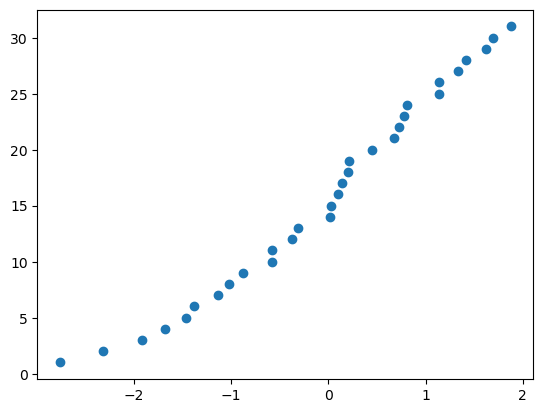

In [24]:
# quick visual check of how the rank ordering works - highest value = highest rank
ts = ds.sel(lon = -0.1, lat = 51.51, method = "nearest").sel(time = slice("1995","2025")).groupby("time.month")[10]
r = ts.rank("time")
plt.scatter(ts, r)

## YTD

In [25]:
for varnm in ["rx1day", "rx5day", "tp", "t2m", "pev"]:
    ds = wrap_lon(xr.open_dataset("data/"+varnm+"-monthly_era5-1deg.nc")[varnm]).sel(lat = slice(-58,None))
    ds = ds.sel(time = ds.time.dt.month <= ds.sel(time = "2025").time.dt.month.max()).resample(time = "YS").mean()

    ranks = ds.sel(time = slice("1995","2025")).rank("time")
    ranks.to_netcdf("ranks-ytd_"+varnm+"_era5-1deg.nc")
    
    rank_2025 = ranks.sel(time = "2025").squeeze()
    rank_2025.to_netcdf("rank2025-ytd_"+varnm+"_era5-1deg.nc")

In [58]:
for varnm in ["spei3", "spei6", "spei12"]:
    ds = xr.open_dataset("rank2025-monthly_"+varnm+"_era5-1deg.nc").isel(month = -1)
    ds.to_netcdf("rank2025-ytd_"+varnm+"_era5-1deg.nc")

## YTD excluding 2024

In [47]:
for varnm in ["rx1day", "rx5day", "tp", "t2m", "pev"]:
    ds = wrap_lon(xr.open_dataset("data/"+varnm+"-monthly_era5-1deg.nc")[varnm]).sel(lat = slice(-58,None))
    ds = ds.sel(time = ds.time.dt.month <= ds.sel(time = "2025").time.dt.month.max()).resample(time = "YS").mean()
    ds = xr.concat([ds.sel(time = slice(None, "2023")), ds.sel(time = "2025")], "time")
    
    ranks = ds.sel(time = slice("1995","2025")).rank("time")
    
    rank_2025 = ranks.sel(time = "2025").squeeze()
    rank_2025.to_netcdf("rank2025-ytd-excl2024_"+varnm+"_era5-1deg.nc")

# Maps

## YTD

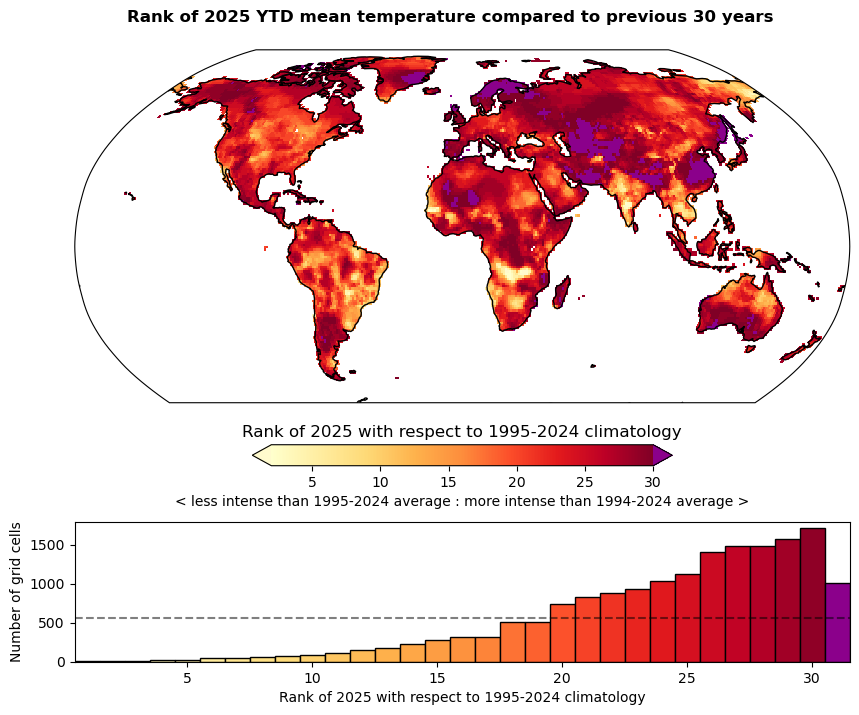

In [55]:
varnm = "t2m"

if varnm in ["tp", "spei3", "spei6", "spei12"]:
    rank_cmap = plt.get_cmap('BrBG')
    rank_cmap.set_under("darkred")
    rank_cmap.set_over("darkblue")
    longname = {"tp" : "precipitation", "spei3" : "SPEI_3", "spei6" : "SPEI_6", "spei12" : "SPEI_12"}[varnm]

elif varnm in ["rx1day", "rx5day"]:
    rank_cmap = plt.get_cmap('YlGnBu')
    # rank_cmap.set_under("darkred")  # low extremes don't make much sense
    rank_cmap.set_over("darkblue")
    longname = {"tp" : "precipitation", "rx1day" : "rx1day", "rx5day" : "rx5day"}[varnm]
    
elif varnm == "t2m":
    rank_cmap = plt.get_cmap('YlOrRd')
    rank_cmap.set_under("lemonchiffon")
    rank_cmap.set_over("darkmagenta")
    longname = "mean temperature"

#=================================================================================================================#

ranks = xr.open_dataset("rank2025-ytd_"+varnm+"_era5-1deg.nc")[varnm]

fig, axs = plt.subplots(ncols = 1, nrows = 2, figsize = (10,8),  dpi = 100, gridspec_kw = {"height_ratios" : [3,1]})
plt.subplots_adjust(wspace = 0.1)

axs[0].set_axis_off()

ax = plt.subplot(211, projection = mapproj)
cbar = ax.pcolormesh(ranks.lon, ranks.lat, ranks, cmap = rank_cmap, vmin = 2, vmax = 30, transform = dataproj)
ax.coastlines()

cbar2 = plt.colorbar(cbar, ax = ax, location = "bottom", fraction = 0.05, pad = 0.1, extend = "both", 
                     label = "< less intense than 1995-2024 average : more intense than 1994-2024 average >")
# cbar2.ax.set_xticks(ticks = np.arange(0.5,11.5,2), labels = [str(v*10)+"%" for v in range(0,11,2)])
cbar2.ax.set_title('Rank of 2025 with respect to 1995-2024 climatology')

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~#

ax = axs[1]

hist_colours = [rank_cmap.get_under()] + [rank_cmap(v) for v in np.arange(0,1,1/29)] + [rank_cmap.get_over()]

h = histogram(ranks, bins = np.arange(0.5, 32.5, 1))
ax.bar(x = range(1,32), height = h, color = hist_colours, edgecolor = "k", width = 1)

ax.set_xmargin(0)
ax.axhline(sum(h) / 31, ls = "--", color = "k", alpha = 0.5)

ax.set_xlabel("Rank of 2025 with respect to 1995-2024 climatology")
ax.set_ylabel("Number of grid cells")

plt.suptitle("Rank of 2025 YTD "+longname+" compared to previous 30 years", fontweight = "bold", y = 0.925)

plt.savefig("fig/rank2025-ytd_"+varnm+"_era5-1deg.png")

### YTD excluding 2024

Text(0.5, 0.925, 'Rank of 2025 YTD mean temperature compared to previous 30 years')

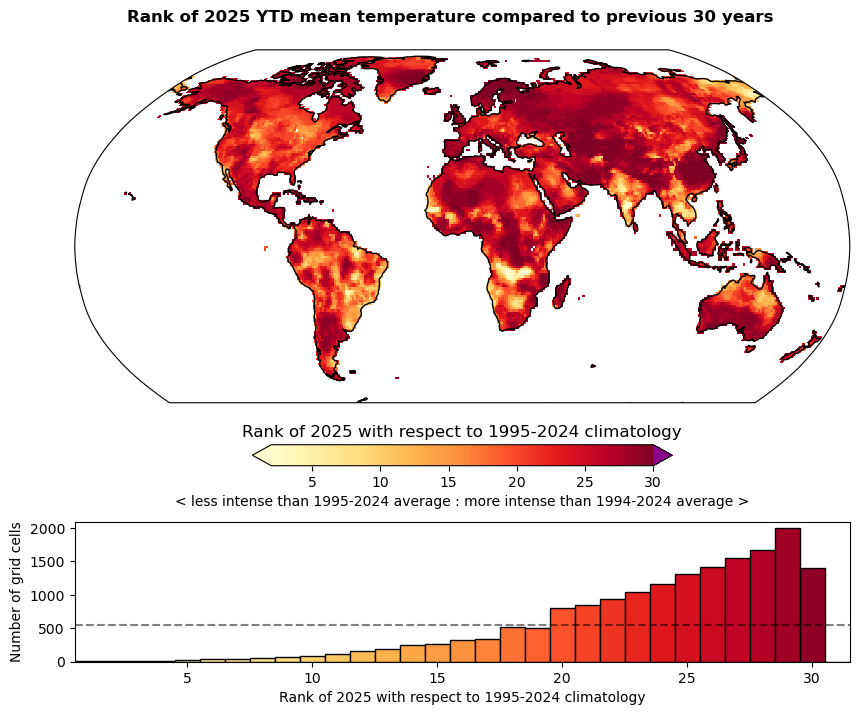

In [48]:
varnm = "t2m"

if varnm in ["tp", "spei3", "spei6", "spei12"]:
    rank_cmap = plt.get_cmap('BrBG')
    rank_cmap.set_under("darkred")
    rank_cmap.set_over("darkblue")
    longname = {"tp" : "precipitation", "spei3" : "SPEI_3", "spei6" : "SPEI_6", "spei12" : "SPEI_12"}[varnm]

elif varnm in ["rx1day", "rx5day"]:
    rank_cmap = plt.get_cmap('YlGnBu')
    # rank_cmap.set_under("darkred")  # low extremes don't make much sense
    rank_cmap.set_over("darkblue")
    longname = {"tp" : "precipitation", "rx1day" : "rx1day", "rx5day" : "rx5day"}[varnm]
    
elif varnm == "t2m":
    rank_cmap = plt.get_cmap('YlOrRd')
    rank_cmap.set_under("lemonchiffon")
    rank_cmap.set_over("darkmagenta")
    longname = "mean temperature"

#=================================================================================================================#

ranks = xr.open_dataset("rank2025-ytd-excl2024_"+varnm+"_era5-1deg.nc")[varnm]

fig, axs = plt.subplots(ncols = 1, nrows = 2, figsize = (10,8),  dpi = 100, gridspec_kw = {"height_ratios" : [3,1]})
plt.subplots_adjust(wspace = 0.1)

axs[0].set_axis_off()

ax = plt.subplot(211, projection = mapproj)
cbar = ax.pcolormesh(ranks.lon, ranks.lat, ranks, cmap = rank_cmap, vmin = 2, vmax = 30, transform = dataproj)
ax.coastlines()

cbar2 = plt.colorbar(cbar, ax = ax, location = "bottom", fraction = 0.05, pad = 0.1, extend = "both", 
                     label = "< less intense than 1995-2024 average : more intense than 1994-2024 average >")
# cbar2.ax.set_xticks(ticks = np.arange(0.5,11.5,2), labels = [str(v*10)+"%" for v in range(0,11,2)])
cbar2.ax.set_title('Rank of 2025 with respect to 1995-2024 climatology')

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~#

ax = axs[1]

hist_colours = [rank_cmap.get_under()] + [rank_cmap(v) for v in np.arange(0,1,1/29)] + [rank_cmap.get_over()]

h = histogram(ranks, bins = np.arange(0.5, 32.5, 1))
ax.bar(x = range(1,32), height = h, color = hist_colours, edgecolor = "k", width = 1)

ax.set_xmargin(0)
ax.axhline(sum(h) / 31, ls = "--", color = "k", alpha = 0.5)

ax.set_xlabel("Rank of 2025 with respect to 1995-2024 climatology")
ax.set_ylabel("Number of grid cells")

plt.suptitle("Rank of 2025 YTD "+longname+" compared to previous 30 years", fontweight = "bold", y = 0.925)

# plt.savefig("fig/rank2025-ytd_"+varnm+"_era5-1deg.png")

# Annual histograms

In [49]:
varnm = "t2m"

if varnm in ["tp", "spei3", "spei6", "spei12"]:
    rank_cmap = plt.get_cmap('BrBG')
    rank_cmap.set_under("darkred")
    rank_cmap.set_over("darkblue")
    longname = {"tp" : "precipitation", "spei3" : "SPEI_3", "spei6" : "SPEI_6", "spei12" : "SPEI_12"}[varnm]

elif varnm in ["rx1day", "rx5day"]:
    rank_cmap = plt.get_cmap('YlGnBu')
    # rank_cmap.set_under("darkred")  # low extremes don't make much sense
    rank_cmap.set_over("darkblue")
    longname = {"tp" : "precipitation", "rx1day" : "rx1day", "rx5day" : "rx5day"}[varnm]
    
elif varnm == "t2m":
    rank_cmap = plt.get_cmap('YlOrRd')
    rank_cmap.set_under("lemonchiffon")
    rank_cmap.set_over("darkmagenta")
    longname = "mean temperature"

In [50]:
ranks = xr.open_dataset("ranks-ytd_"+varnm+"_era5-1deg.nc")[varnm]

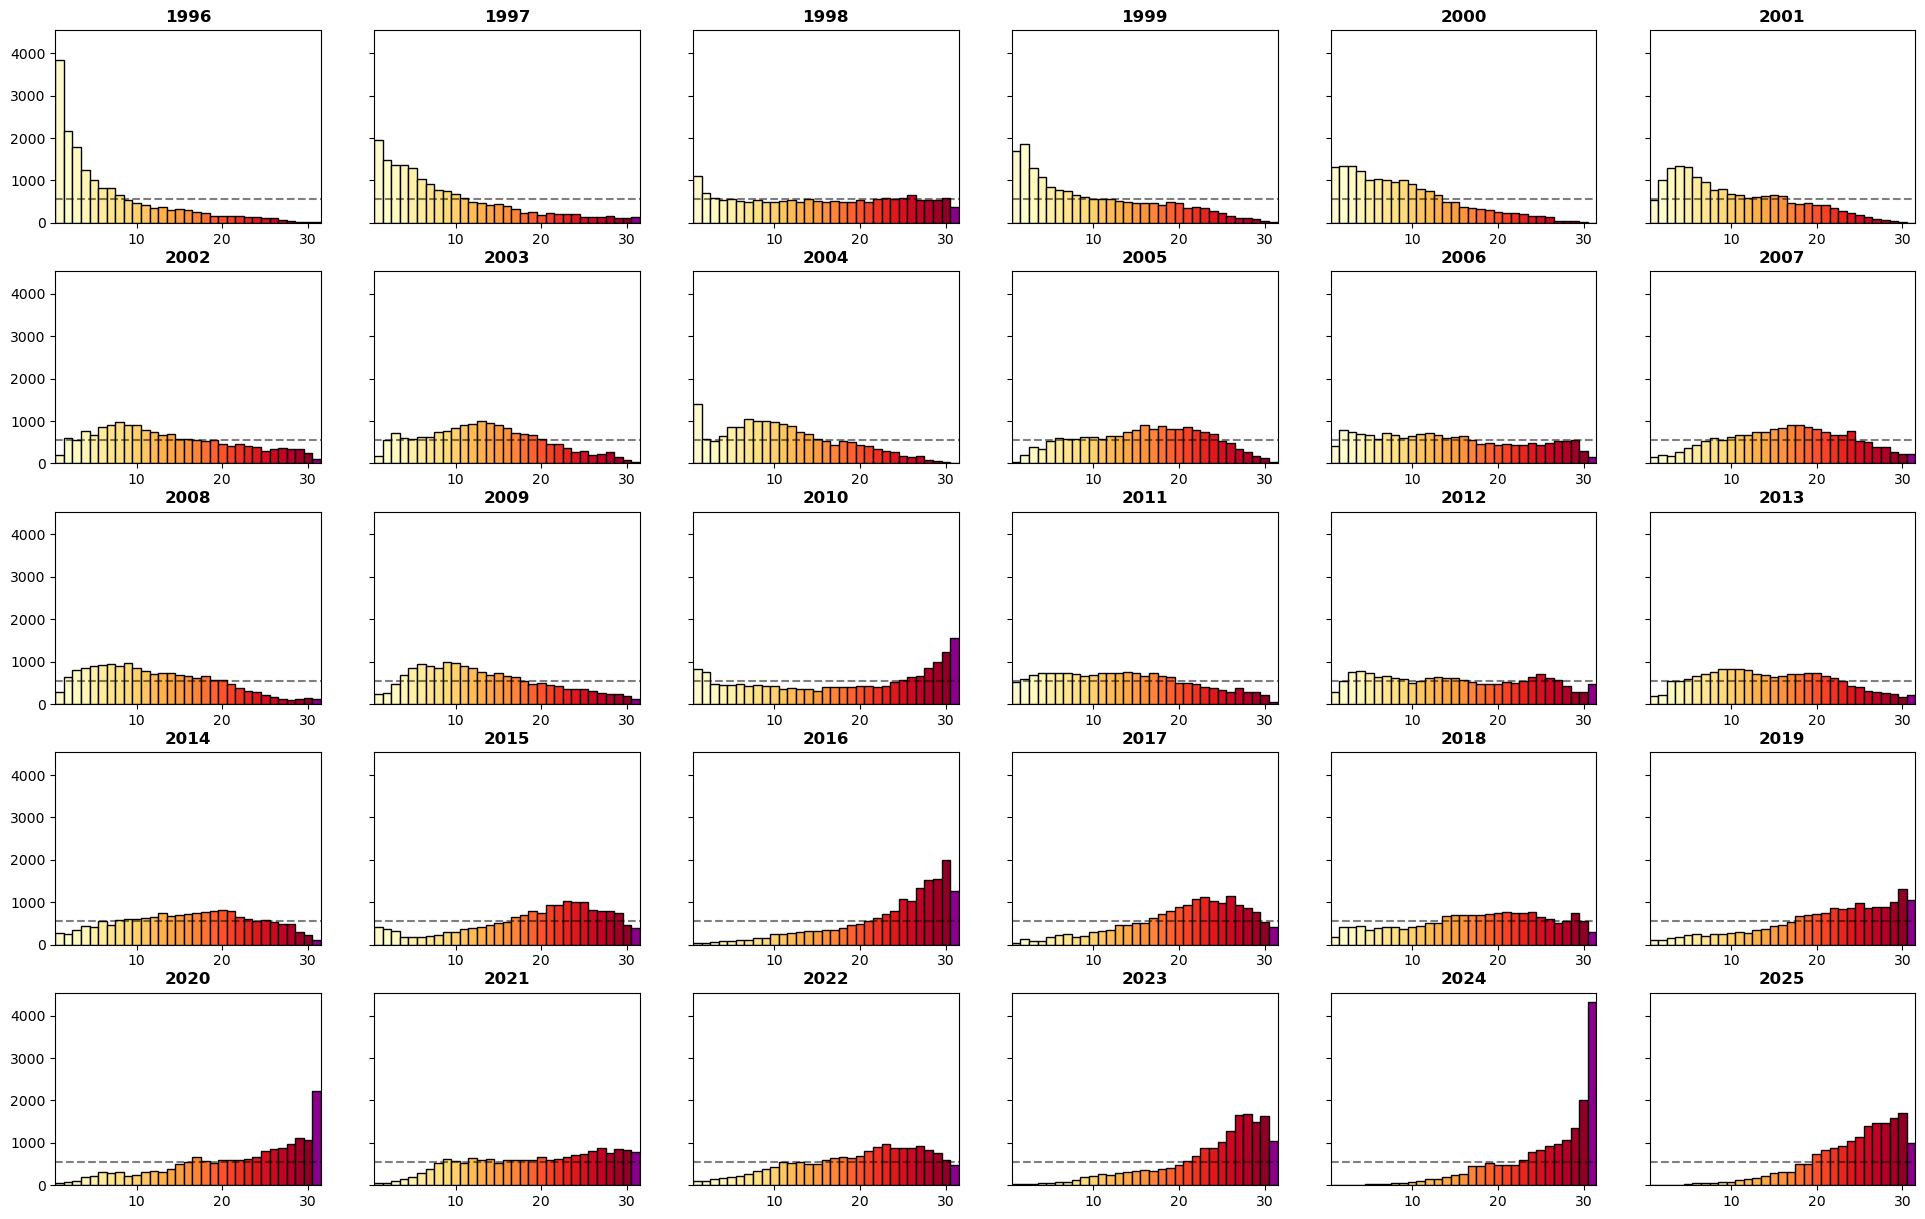

In [51]:
nc = 6; nr = 5
fig, axs = plt.subplots(ncols = nc, nrows = nr, dpi = 100, figsize = (nc * 4, nr * 3), sharey = True) 
plt.subplots_adjust(hspace = 0.25)
hist_colours = [rank_cmap.get_under()] + [rank_cmap(v) for v in np.arange(0,1,1/29)] + [rank_cmap.get_over()]

for i in range(nc*nr):
    ax = axs.flatten()[i]
    r = ranks.isel(time = i+1)

    h = histogram(r, bins = np.arange(0.5, 32.5, 1))
    ax.bar(x = range(1,32), height = h, color = hist_colours, edgecolor = "k", width = 1)
    
    ax.set_xmargin(0)
    ax.axhline(sum(h) / 31, ls = "--", color = "k", alpha = 0.5)
    ax.set_title(str(r.time.dt.year.values), fontweight = "bold")